In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset
from torchsummary import summary
import jammy_flows

import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append('..')

from helper import normalize, denormalize, get_normalized_data
from models import Medium_NF_CNN
# Kernel restart required after renaming/adding a class to models.py (cache problem)

torchdiffeq not found - no support for continuous flows. Install *torchdiffeq* if support is desired!
Meander not installed... contours can not be calculated.
Healpy not installed... spherical contours can not be calculated.
package *astropy* not found -> if you want to use plotting functionality for adaptive grids, install *astropy*!
package *mhealpy* not found -> if you want to use plotting functionality for adaptive grids, install *mhealpy*!
Cannot use healpy functionality. Install healpy, if you need to do entropy scanning!


In [2]:
# Downloading the files, if not already done
from huggingface_hub import hf_hub_download

data_dir = '../data/galah4'
filenames=['labels.npy', 'spectra.npy']

for filename in filenames:
    if not os.path.exists(os.path.join(data_dir, filename)):
        hf_hub_download(
            repo_id='simbaswe/galah4', 
            filename=filename, 
            repo_type='dataset', 
            local_dir='../data/galah4/'
        )
        print(filename, 'downloaded')

In [3]:
# Getting normalized data from the .npy-files:
# Only spectra.npy and labels.npy usable with the given helper.py-function:

spectra, labels, spectra_length, n_labels, label_names, ranges = get_normalized_data(data_dir)

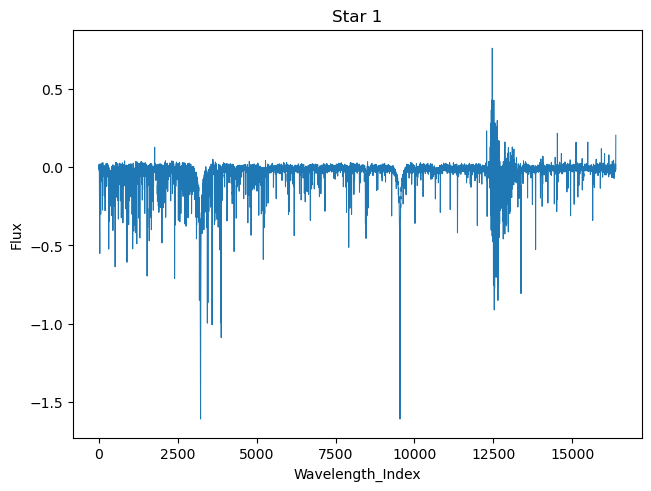

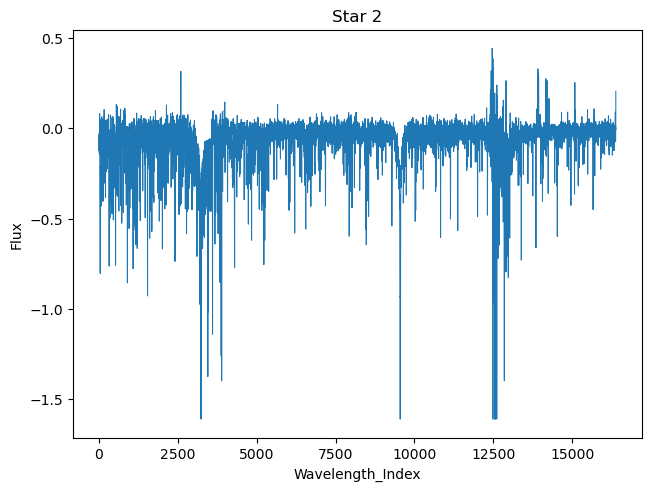

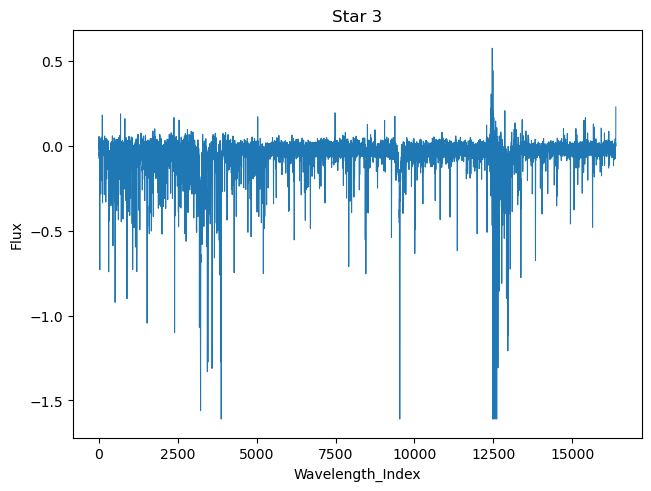

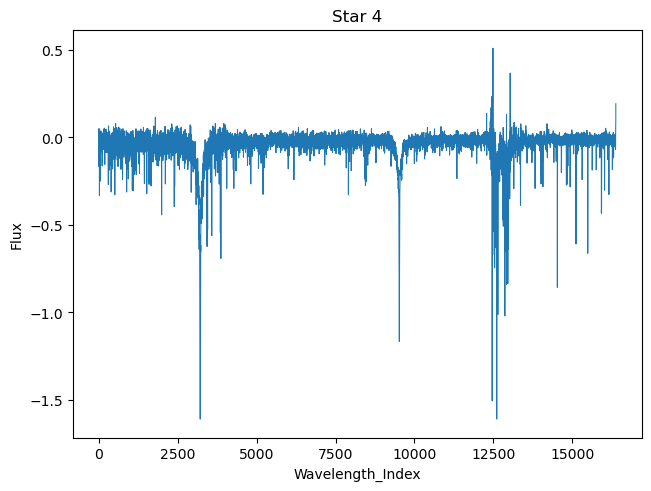

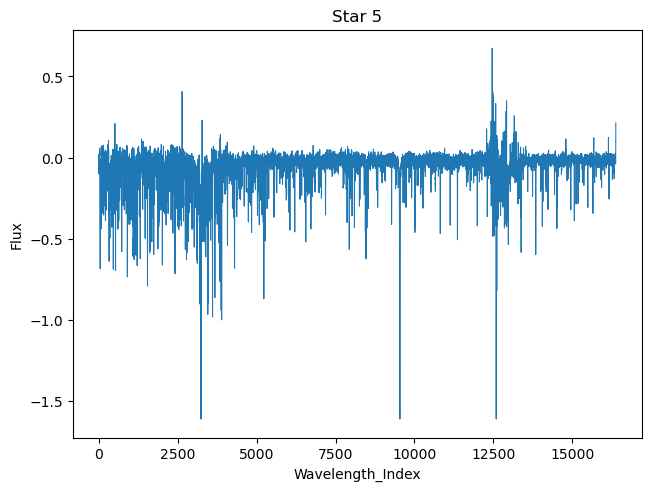

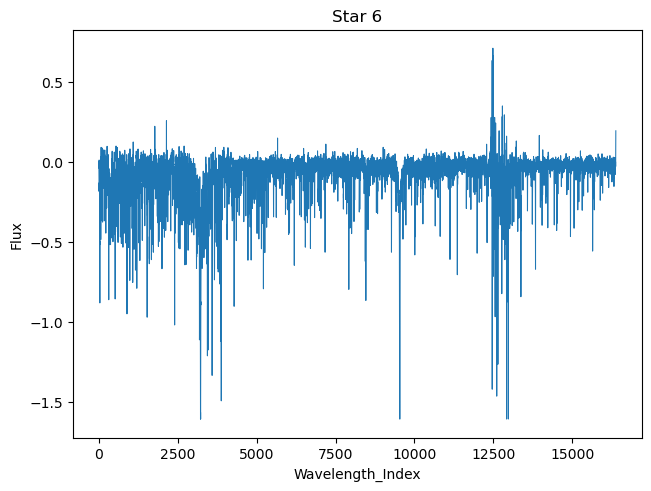

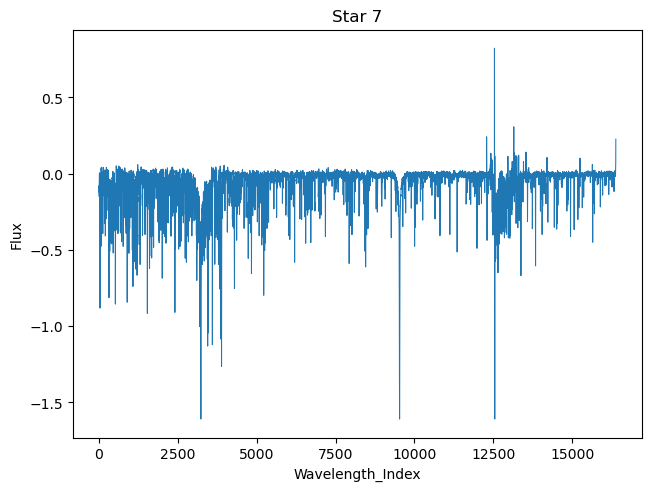

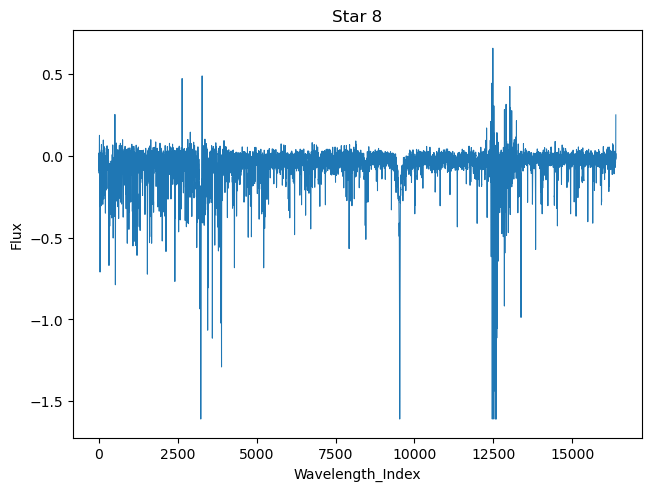

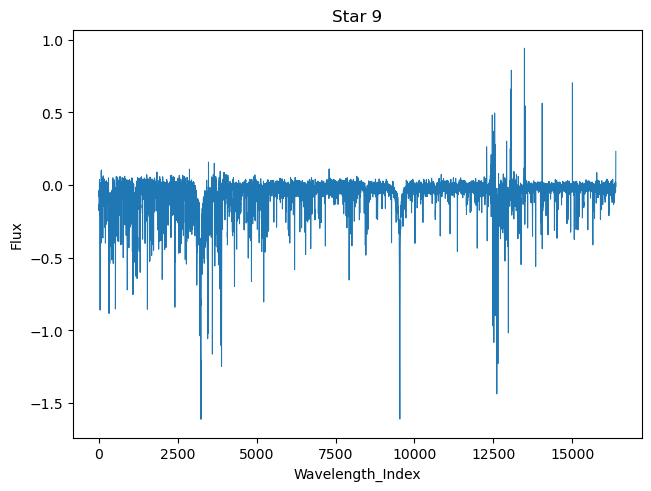

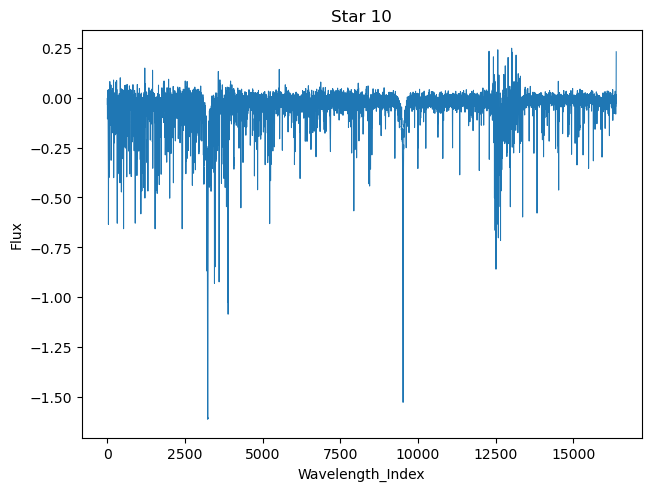

In [4]:
# Plotting a few spectra (just kept it for better visualization of the data in this notebook.)
for i in range(10):
    fig, ax = plt.subplots(1, 1, layout='constrained')
    ax.plot(spectra[i], lw=0.75) # lw = linewidth. Smaller to increase visibility.
    ax.set(
        title=(f'Star {i+1}'),
        xlabel=('Wavelength_Index'),
        ylabel=('Flux')
    )

**Implementing a CNN network**

In [5]:
# Defining the device pytorch in running on
device = (
    'cuda' if torch.cuda.is_available()
    else 'cpu'
)

# Defining the Dataset-class to connect the dataset-points of X and y and define a length.
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Constructing the data tensors for pytorch
X_tensor = (
    torch.as_tensor(spectra, dtype=torch.float32)
    .to(device)
)

y_tensor = (
    torch.as_tensor(labels, dtype=torch.float32)
    .to(device)
)
    
# Splitting the data and creating the dataset (Maybe better do define the fractions in the beginning in one 'chapter' of setting.)
n_samples = spectra.shape[0]

train_size = int(0.7 * n_samples)
val_size = int(0.15 * n_samples)
test_size = n_samples - train_size - val_size

# Using the customized dataset class for our dataset
dataset = CustomDataset(X_tensor, y_tensor)

train_dataset, val_dataset, test_dataset = random_split(
    dataset, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(420) # Fixed seed for better comparison.
)

# Dataloaders for the CNN where the training parameters are set (e.g. batch size)
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

In [6]:
# train_model definition from the helper.py
# Slightly rewritten to also calculate and safe the mean and log_std for pull distribution
import time
import copy
def train_model(model, conditional_pdf, train_loader, val_loader, loss_function, learning_rate, num_epochs, patience,
                device, plot_fn=None, plot_interval=10, plot_kwargs=None, model_name=None):
    """
    Trains a given model using the provided training and validation data loaders, loss function, and optimizer.

        Parameters
        ----------
        model : torch.nn.Module
            The neural network model to be trained.
        train_loader : torch.utils.data.DataLoader
            DataLoader for the training dataset.
        val_loader : torch.utils.data.DataLoader
            DataLoader for the validation dataset.
        loss_function : torch.nn.Module
            Loss function to be used for training.
        learning_rate : float
            learning rate
        num_epochs : int
            Number of epochs to train the model.
        patience : int
            Number of epochs with no improvement after which training will be stopped.
        device : torch.device
            Device on which to perform training (e.g., 'cpu' or 'cuda').
        plot_fn : callable, optional
            Function to plot the model predictions during training. Default is None.
        plot_interval : int, optional
            Interval at which to plot the model predictions during training. Default is 10.
        plot_kwargs : dict, optional
            Additional keyword arguments to be passed to the plot function. Default is None.
        model_name : str, optional
            Name of the model for saving the best model. Default is None.
            If provided, the best model will be saved to the "models" directory with the given name.

        Returns
        -------
        tuple
            A tuple containing two lists:
            - train_losses (list of float): List of average training losses for each epoch.
            - val_losses (list of float): List of average validation losses for each epoch.
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model = None

    for epoch in range(num_epochs):
        start_time = time.time()  # Start the timer for this epoch
        
        # Training phase
        model.train()
        total_train_loss = 0.0
        for step, (batch_spectra, batch_labels) in enumerate(train_loader):
            batch_spectra, batch_labels = batch_spectra.to(device).unsqueeze(1), batch_labels.to(device)  # Add channel dimension for CNNs
            optimizer.zero_grad()

            # Loss Function
            predictions = model(batch_spectra)
            loss=loss_function(batch_labels, predictions, conditional_pdf)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            

            total_train_loss += loss.item()

            # Print progress every 10th step, updating the same line
            if (step + 1) % 10 == 0:
                sys.stdout.write(f"\rEpoch [{epoch + 1}/{num_epochs}], Step [{step + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")
                sys.stdout.flush()

        sys.stdout.write("\n")  # Move to the next line after the epoch

        # Validation phase
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for batch_spectra, batch_labels in val_loader:
                batch_spectra, batch_labels = batch_spectra.to(device).unsqueeze(1), batch_labels.to(device)

                # Loss Function (Look-Up functools.partial for a use in here)
                predictions = model(batch_spectra)
                val_loss=loss_function(batch_labels, predictions, conditional_pdf)

                total_val_loss += val_loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)

        # Store losses for plotting
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        # Print epoch summary
        epoch_time = time.time() - start_time  # Calculate epoch time
        print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Time: {epoch_time:.2f} seconds")

        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model = copy.copy(model.state_dict())
            # Save the best model to the "models" directory
            if not os.path.exists('models'):
                os.makedirs('models')
            if model_name is not None:
                torch.save(best_model, f"models/{model_name}_best.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

        if(epoch%plot_interval==0):
            if(plot_fn is not None):

                assert(plot_kwargs is not None)

                assert("test_loader" in plot_kwargs.keys())
                assert("ranges" in plot_kwargs.keys())
                assert("plot_folder" in plot_kwargs.keys())

                plot_fn(model,
                        plot_kwargs["test_loader"],
                        loss_function,
                        device,
                        plot_kwargs["ranges"],
                        train_losses,
                        val_losses,
                        plot_folder=plot_kwargs["plot_folder"],
                        suffix="epoch_%.5d" % epoch)
        
    return train_losses, val_losses, best_model

In [10]:
# Loss function (NLL loss function for an uncertainty_prediction)
class Custom_loss_function(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, batch_labels, predictions, conditional_pdf):
        log_pdfs, _, _ = conditional_pdf(batch_labels, amortization_parameters=predictions)
        return -log_pdfs.mean()

####################################
### Defining the jammy_flow PDFs ###
####################################

#Initializing a directory for saving the results
results = {}

# Iterating over all three normalizing flows
for flow_function in ['t']:    
    custom_pdf = jammy_flows.pdf('e3', flow_function, amortize_everything=True, amortization_mlp_use_custom_mode=True)
    # amortize_everythin=True gives every datapoint its own parameter (f(x) = CNN(x)). Not a single global one.
    # amortization_mlp_use_custom_mode=True gives control over the used network. In this case, only our own custom network is used.

    num_params = custom_pdf.total_number_amortizable_params
    print('Used flow function: ', flow_function)
    print('Number of pdf parameters: ', num_params)
    
    ##############################
    ### Defining the CNN model ###
    ##############################

    model_choice = 'Medium_NF_CNN' # Same model as in the Solution from last week (had good results and a decent training time on my laptop -> Same Dataset = Same Model.
    # Just added another Conv1D-Block and doubled the amoun tof feature maps to make the network deeper. - Especially for the Gaussian Flows requiring many params.)

    # Failsafe from the solution from last week.
    if model_choice == 'Medium_NF_CNN':
        model = Medium_NF_CNN(num_params)
    else:
        raise ValueError('Invalid model choise. Please select "TinyCNNEncoder".')

    # Model Summary
    summary(model, input_size=(1, spectra_length))
    print('\n \n')

    ################
    ### Training ###
    ################

    conditional_pdf = custom_pdf
    learning_rate = 5e-4
    num_epochs = 100
    patience = 10

    loss_function = Custom_loss_function()
    train_losses, val_losses, best_model = train_model(model, conditional_pdf, train_loader, val_loader, loss_function, learning_rate, num_epochs, patience, device)

    # Saving the results in a 2-level dictionary
    results[flow_function] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_model': best_model,
        'flow_function': flow_function
    }

sub-manifold (0 - e3 - t) and intra-manifold flow (0 - t) - using *default* options
Used flow function:  t
Number of pdf parameters:  6
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1            [-1, 10, 16380]              60
              ReLU-2            [-1, 10, 16380]               0
       BatchNorm1d-3            [-1, 10, 16380]              20
           Dropout-4            [-1, 10, 16380]               0
         AvgPool1d-5             [-1, 10, 5460]               0
            Conv1d-6             [-1, 20, 5456]           1,020
              ReLU-7             [-1, 20, 5456]               0
       BatchNorm1d-8             [-1, 20, 5456]              40
           Dropout-9             [-1, 20, 5456]               0
        AvgPool1d-10             [-1, 20, 1818]               0
           Conv1d-11             [-1, 40, 1814]           4,040
             ReLU-12           

In [11]:
# train_model definition from the helper.py
# Slightly rewritten for the changed loss_function
def evaluate_model(model, conditional_pdf, test_loader, loss_function, device):
    """
    Evaluate the given model on the test dataset.

    Parameters
    ----------
    model : torch.nn.Module
        The neural network model to evaluate.
    test_loader : torch.utils.data.DataLoader
        DataLoader for the test dataset.
    loss_function : callable
        Loss function used to compute the loss.
    device : torch.device
        Device on which to perform computations (e.g., 'cpu' or 'cuda').

    Returns
    -------
    all_predictions : numpy.ndarray
        Array of denormalized predictions made by the model.
    all_true_labels : numpy.ndarray
        Array of denormalized true labels from the test dataset.
    """
    print("Evaluating model on the test dataset...")
    model.eval()
    total_test_loss = 0.0
    all_predictions = []
    all_true_labels = []
    all_pulls = []

    first_batch_spectra=None
    first_batch_labels=None

    with torch.no_grad():
        for batch_index, (batch_spectra, batch_labels) in enumerate(test_loader):
            batch_spectra, batch_labels = batch_spectra.to(device).unsqueeze(1), batch_labels.to(device)

            predictions = model(batch_spectra)
            test_loss=loss_function(batch_labels, predictions, conditional_pdf)

            total_test_loss += test_loss.item()
            all_predictions.append(predictions.cpu())
            all_true_labels.append(batch_labels.cpu())

            # Pull distribution values for the best_model:

            mean = predictions[:, :n_labels]
            log_std = predictions[:, n_labels:2*n_labels]
            pull = (mean - batch_labels) / torch.exp(log_std)
            all_pulls.append(pull.cpu())
            
            if(batch_index==0):
                first_batch_spectra=batch_spectra
                first_batch_labels=batch_labels

    avg_test_loss = total_test_loss / len(test_loader)
    print(f"Final Test Loss: {avg_test_loss:.4f}")
    return torch.cat(all_predictions).numpy(), torch.cat(all_true_labels).numpy(), first_batch_spectra, first_batch_labels, torch.cat(all_pulls).numpy()

sub-manifold (0 - e3 - t) and intra-manifold flow (0 - t) - using *default* options
Evaluating model on the test dataset...
Final Test Loss: -3.1246


"  \n    # Taking example data from the test_loader\n    sample_spectra, sample_labels = next(iter(test_loader)) # Taking only the first batch of the batch-iteration\n    x_batch = torch.zeros(1000, 3)\n    \n    # Getting the pdf\n    x_batch[:, 0] = torch.linspace(sample_labels[:, 0].min(), sample_labels[:, 0].max(), 1000)\n    logpdf_evaluations01,_,_=custom_pdf.forward(x_values01, amortization_parameters=model(sample_spectra))\n\n    \n    x_batch[:, 1] = torch.linspace(sample_labels[:, 1].min(), sample_labels[:, 1].max(), 1000)\n    logpdf_evaluations02,_,_=custom_pdf.forward(x_values02, amortization_parameters=model(sample_spectra))\n\n    x_batch[:, 2] = torch.linspace(sample_labels[:, 2].min(), sample_labels[:, 2].max(), 1000)\n\n    sample_spectra = sample_spectra.unsqueeze(1)\n    amortization_parameters=model(sample_spectra)\n\n    logpdf_evaluations,_,_=custom_pdf.forward(x_batch, amortization_parameters=amortization_parameters)\n\n    fig, (ax1, ax2, ax3) = plt.subplots(3,

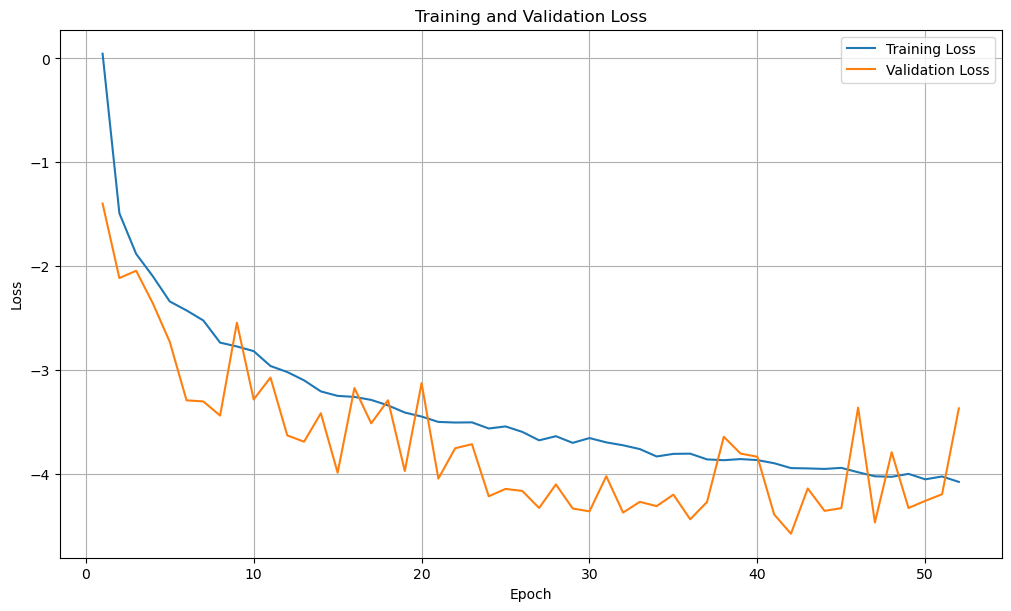

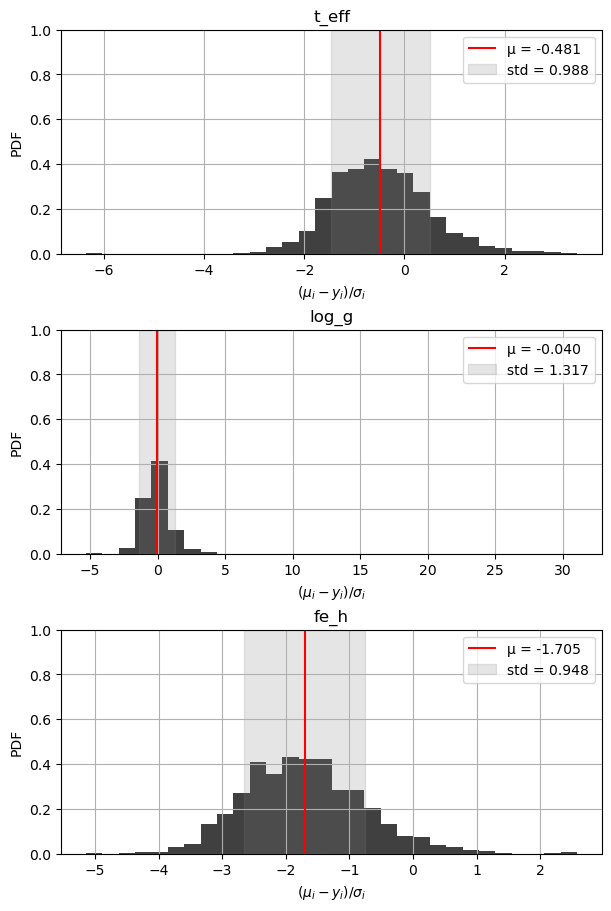

In [15]:
def visualize_pdf(self, input_data, filename, samplesize=1000, batch_index=0, truth=None):
        """
        Visualizes the probability density function (PDF) of the given input data using a normalizing flow model.

        The function generates samples from the normalizing flow (using the sample() function)
        and plots the histogram of the samples together with a Gaussian approximation.

        Parameters
        ----------
        input_data : torch.Tensor
            The input data tensor from which to pick one batch item for visualization.
        filename : str
            The filename where the resulting plot will be saved.
        samplesize : int, optional
            The number of samples to generate for the PDF visualization (default is 10000).
        batch_index : int, optional
            The index of the batch item to visualize (default is 0).
        truth : torch.Tensor, optional
            The true values of the labels, used for comparison in the plot (default is None).

        Returns
        -------
        None
        """
        # pick out one input from batch
        input_bitem = input_data[batch_index : batch_index + 1]

        # get the flow parameters (by passing the input data through the CNN encoder network)
        flow_params = self.encoder(input_bitem)

        # sample from the normalizing flow (i.e. samples are drawn from the base distribution and transformed by the flow
        # using the change-of-variable formula)
        samples = self.sample(flow_params, samplesize_per_batchitem=samplesize)
        # the rest of the code is just plotting.

        # we only have 1 batch item
        samples = samples.squeeze(0)

        # plot three 1-dimensional distributions together with normal approximation,
        # so we calculate the mean and std of the samples
        mean = samples.mean(dim=0).cpu().numpy()
        std = samples.std(dim=0).cpu().numpy()
        samples = samples.cpu().numpy()

        fig, axdict = plt.subplots(3, 1)
        for dim_ind in range(3):
            # plot the histogram of the samples
            axdict[dim_ind].hist(samples[:, dim_ind], color="k", density=True, bins=50, alpha=0.5, label="density based on samples")

            # plot the Gaussian approximation
            min_sample = samples[:, dim_ind].min()
            max_sample = samples[:, dim_ind].max()
            xvals = np.linspace(min_sample, max_sample, 1000)
            yvals = norm.pdf(xvals, loc=mean[dim_ind], scale=std[dim_ind])
            axdict[dim_ind].plot(xvals, yvals, color="green", label="Gaussian approximation")

            # plot the true value if it is given
            if truth is not None:
                true_value = truth[dim_ind].cpu().item()
                axdict[dim_ind].axvline(true_value, color="red", label="true value")

            # plot the legend only for the first panel
            if dim_ind == 0:
                axdict[dim_ind].legend()

        plt.savefig(filename)
        plt.close(fig)


############################################
### Final evaluation on the test dataset ###
############################################
for flow_function in ['t']:    
    custom_pdf = jammy_flows.pdf('e3', flow_function, amortize_everything=True, amortization_mlp_use_custom_mode=True)

    model.load_state_dict(results[flow_function]['best_model'])  # Load the best model
    # save the best model to the "models" directory
    if not os.path.exists('models'):
        os.makedirs('models')
    torch.save(results[flow_function]['best_model'], f'models/{model_choice}_{flow_function}_best.pth')
    model.to(device)

    all_predictions, all_true_labels,_,_, all_pulls = evaluate_model(model, custom_pdf, test_loader, loss_function, device)
    all_predictions = denormalize(all_predictions[:, :n_labels], ranges)  # Denormalize predictions (only mean)
    all_true_labels = denormalize(all_true_labels[:, :n_labels], ranges)  # Denormalize true labels (onlt mean)

    # Plot training and validation loss
    fig, ax = plt.subplots(1, 1, figsize=(10, 6), layout='constrained')
    ax.plot(range(1, len(results[flow_function]['train_losses']) + 1), results[flow_function]['train_losses'], label='Training Loss')
    ax.plot(range(1, len(results[flow_function]['val_losses']) + 1), results[flow_function]['val_losses'], label='Validation Loss')
    ax.set(
        #yscale=('log'),
        xlabel=('Epoch'),
        ylabel=('Loss')
    )
    ax.set_title('Training and Validation Loss')
    ax.legend()
    ax.grid(True)
    
    ################################################################
    ### Pull Distribution to evaluate the uncertainty prediction ###
    ################################################################

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 9), layout='constrained')
    plt.rcParams['axes.grid']=True

    ax1.hist(all_pulls[:, 0], 30, density=True, color='black', alpha=0.75)
    ax1.vlines(np.mean(all_pulls[:, 0]), 0, 1, color='red', label=f'µ = {np.mean(all_pulls[:, 0]):.3f}')
    ax1.axvspan(xmin=np.mean(all_pulls[:, 0])-np.std(all_pulls[:, 0]), xmax=np.mean(all_pulls[:, 0])+np.std(all_pulls[:, 0]), color='gray', alpha=0.2, label=f'std = {np.std(all_pulls[:, 0]):.3f}')

    ax2.hist(all_pulls[:, 1], 30, density=True, color='black', alpha=0.75)
    ax2.vlines(np.mean(all_pulls[:, 1]), 0, 1, color='red', label=f'µ = {np.mean(all_pulls[:, 1]):.3f}')
    ax2.axvspan(xmin=np.mean(all_pulls[:, 1])-np.std(all_pulls[:, 1]), xmax=np.mean(all_pulls[:, 1])+np.std(all_pulls[:, 1]), color='gray', alpha=0.2, label=f'std = {np.std(all_pulls[:, 1]):.3f}')

    ax3.hist(all_pulls[:, 2], 30, density=True, color='black', alpha=0.75)
    ax3.vlines(np.mean(all_pulls[:, 2]), 0, 1, color='red', label=f'µ = {np.mean(all_pulls[:, 2]):.3f}')
    ax3.axvspan(xmin=np.mean(all_pulls[:, 2])-np.std(all_pulls[:, 2]), xmax=np.mean(all_pulls[:, 2])+np.std(all_pulls[:, 2]), color='gray', alpha=0.2, label=f'std = {np.std(all_pulls[:, 2]):.3f}')

    ax1.set(
        ylim=(0, 1),
        xlabel=(r'$(µ_i - y_i)/\sigma_i$'),
        ylabel=('PDF')
    )
    ax1.legend()
    ax1.set_title(label_names[0])
    ax2.set(
        ylim=(0, 1),
        xlabel=(r'$(µ_i - y_i)/\sigma_i$'),
        ylabel=('PDF')
    )
    ax2.legend()
    ax2.set_title(label_names[1])
    ax3.set(
        ylim=(0, 1),
        xlabel=(r'$(µ_i - y_i)/\sigma_i$'),
        ylabel=('PDF')
    )
    ax3.legend()
    ax3.set_title(label_names[2])

    ##################################################
    ### Plotting some PDFs of the Normalizing Flow ###
    ##################################################
'''  
    # Taking example data from the test_loader
    sample_spectra, sample_labels = next(iter(test_loader)) # Taking only the first batch of the batch-iteration
    x_batch = torch.zeros(1000, 3)
    
    # Getting the pdf
    x_batch[:, 0] = torch.linspace(sample_labels[:, 0].min(), sample_labels[:, 0].max(), 1000)
    logpdf_evaluations01,_,_=custom_pdf.forward(x_values01, amortization_parameters=model(sample_spectra))

    
    x_batch[:, 1] = torch.linspace(sample_labels[:, 1].min(), sample_labels[:, 1].max(), 1000)
    logpdf_evaluations02,_,_=custom_pdf.forward(x_values02, amortization_parameters=model(sample_spectra))

    x_batch[:, 2] = torch.linspace(sample_labels[:, 2].min(), sample_labels[:, 2].max(), 1000)

    sample_spectra = sample_spectra.unsqueeze(1)
    amortization_parameters=model(sample_spectra)

    logpdf_evaluations,_,_=custom_pdf.forward(x_batch, amortization_parameters=amortization_parameters)

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 9), layout='constrained')
    plt.rcParams['axes.grid']=True

    ax1.hist(sample_labels[:, 0], density=True, bins=50, label='Test data')
    ax1.plot(x_batch[:, 0], logpdf_evaluations[:, 0].exp(), color='red')
    
    ax2.hist(sample_labels[:, 1], density=True, bins=50, label='Test data')
    ax2.plot(x_batch[:, 0], logpdf_evaluations[:, 0].exp(), color='red')
    
    ax3.hist(sample_labels[:, 2], density=True, bins=50, label='Test data')
    ax3.plot(x_batch[:, 0], logpdf_evaluations[:, 0].exp(), color='red')
'''